# Телеметрія: як пілоти проходять трасу

Продовження основного аналізу (`final_project.ipynb`). Там результат вимірювався часом кола —
одним числом на гонку. Тут ми розкладаємо коло на ділянки й дивимось, **де саме** втрачається час.

Два питання:

1. **Повороти.** Каталог поворотів кожної траси будується автоматично з кривизни траєкторії:
   напрямок, кут, радіус. Далі порівнюємо, як той самий поворот проходять напарники — тобто
   пілоти в однаковій машині.
2. **Прямі.** Головна технічна інтрига 2026 року — менеджмент енергії за новим регламентом.
   Крива швидкості вздовж прямої показує, у кого тяга тримається до кінця, а в кого сідає.

**Обмеження методу.** `location` приходить із частотою близько 4 Гц. На 250 км/год це точка
кожні ~17 метрів, тож швидкість в апексі й на виході вимірюється надійно, а **точку початку
гальмування — ні**: вона просто провалюється між семплами.

In [1]:
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import psycopg

sys.path.insert(0, "analysis")
import telemetry as T

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
BLUE, GREEN, RED = "#4C72B0", "#55A868", "#C44E52"

conn = psycopg.connect("postgresql:///f1_2026")

TRACKS = {
    "Belgian Grand Prix":   {"коротко": "Спа",        "офіційно поворотів": 19},
    "Hungarian Grand Prix": {"коротко": "Хунгароринг", "офіційно поворотів": 14},
    "Monaco Grand Prix":    {"коротко": "Монако",      "офіційно поворотів": 19},
    "British Grand Prix":   {"коротко": "Сільверстоун","офіційно поворотів": 18},
}

## 1. Побудова каталогу поворотів

Беремо найшвидше коло кваліфікації: там немає ні трафіку, ні стратегії, ні різниці в паливі.

Координати переводимо в метри, розкладаємо на рівномірну сітку по дистанції (при змінному кроці
похідні нестабільні), згладжуємо і рахуємо кривизну:

$$k = \frac{x'y'' - y'x''}{(x'^2 + y'^2)^{3/2}}$$

Знак кривизни дає напрямок повороту, інтеграл по ділянці — кут, обернена величина в апексі — радіус.

In [2]:
# Калібрування одиниць: у OpenF1 координати задані в 1/10 метра.
laps = T.fastest_laps(conn, "Belgian Grand Prix", 2026, "Qualifying")
ref = laps.iloc[0]
lap = T.load_lap(conn, ref.session_key, ref.driver_id, ref.date_start, float(ref.lap_duration))
gref = T.resample(lap)

print(f"еталонне коло: {ref.driver} ({ref.team}), {ref.lap_duration:.3f} с")
print(f"точок телеметрії: {len(lap)}  (~{len(lap)/ref.lap_duration:.1f} Гц)")
print(f"довжина за геометрією: {gref['distance'].iloc[-1]:.0f} м")
print(f"офіційна довжина Спа:  7004 м")
print("розбіжність від того, що ламана зрізає повороти")

еталонне коло: ANT (Mercedes), 104.361 с
точок телеметрії: 395  (~3.8 Гц)
довжина за геометрією: 6925 м
офіційна довжина Спа:  7004 м
розбіжність від того, що ламана зрізає повороти


In [3]:
k_ref = T.curvature(gref)
corners_spa = T.detect_corners(gref, k_ref)
straights_spa = T.detect_straights(gref, k_ref)

print(f"знайдено поворотів: {len(corners_spa)}")
corners_spa[["corner", "start_m", "apex_m", "direction", "angle_deg", "radius_m", "apex_speed"]]

знайдено поворотів: 15


,corner,start_m,apex_m,direction,angle_deg,radius_m,apex_speed
0,1,300.0,355.0,правий,149,22,80
1,2,1065.0,1100.0,правий,47,100,301
2,3,2325.0,2370.0,правий,57,59,156
3,4,2425.0,2455.0,лівий,61,58,161
4,5,2545.0,2585.0,правий,73,78,194
5,6,2925.0,2975.0,правий,179,45,125
6,7,3175.0,3235.0,лівий,78,65,195
7,8,3710.0,3805.0,лівий,69,105,269
8,9,3900.0,3935.0,лівий,54,118,266
9,10,4375.0,4470.0,правий,93,66,179


Каталог упізнається без підказок:

- **поворот 1** — 149° праворуч, радіус 22 м, апекс 80 км/год → шпилька Ла-Сурс;
- **поворот 2** — 47° праворуч, радіус 100 м, апекс **301 км/год** → О-Руж і Радійон, пройдені майже плоско;
- **повороти 14–15** — швидка зв'язка правий-лівий на ~80 км/год → шикана Бус-Стоп;
- **найдовша пряма 1050 м** між поворотами 2 і 3 → пряма Кеммел.

Тобто алгоритм відтворив упізнавану геометрію Спа, не знаючи про неї нічого.

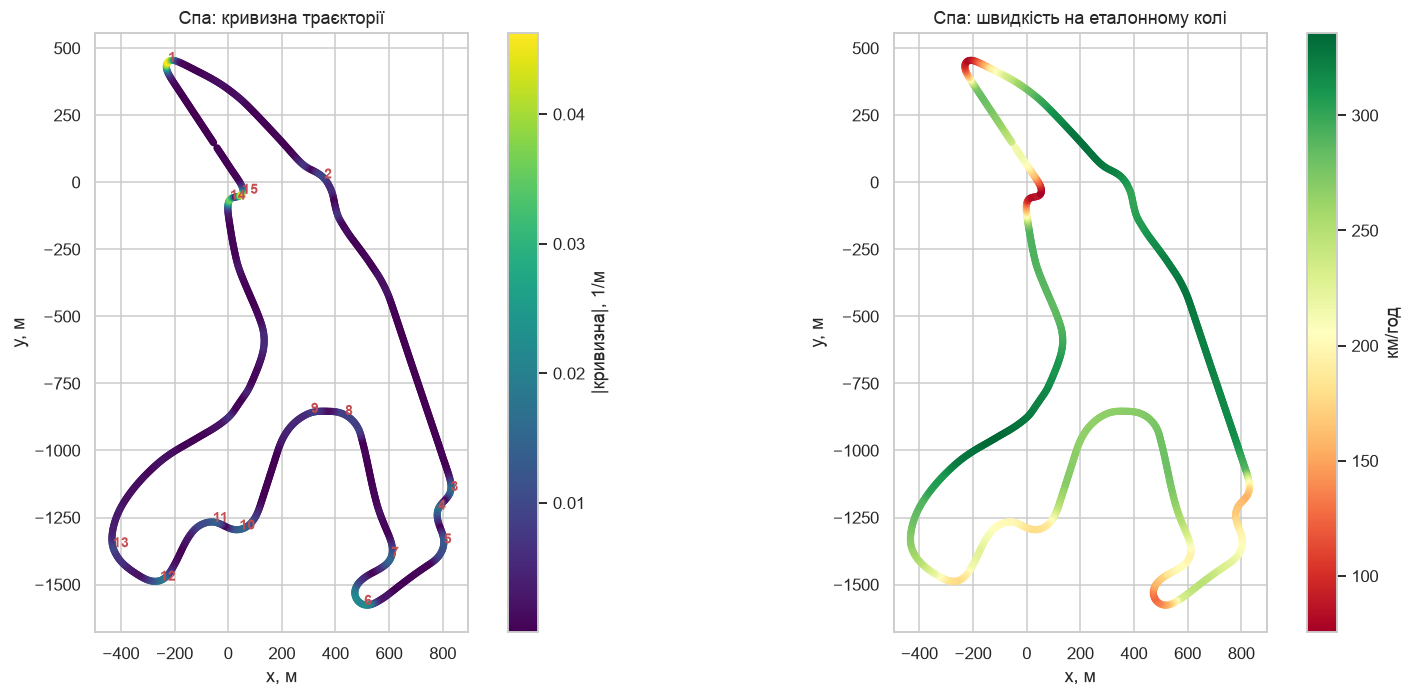

In [4]:
# Карта траси, розфарбована за кривизною
fig, ax = plt.subplots(1, 2, figsize=(15, 6.5))

sc = ax[0].scatter(gref["x_s"], gref["y_s"], c=np.abs(k_ref), s=14, cmap="viridis")
ax[0].set_title("Спа: кривизна траєкторії"); ax[0].set_aspect("equal")
ax[0].set_xlabel("x, м"); ax[0].set_ylabel("y, м")
plt.colorbar(sc, ax=ax[0], label="|кривизна|, 1/м")
for _, c in corners_spa.iterrows():
    i = int(c["apex_m"] / T.GRID_STEP_M)
    ax[0].annotate(str(int(c["corner"])), (gref["x_s"][i], gref["y_s"][i]),
                   fontsize=9, fontweight="bold", color=RED)

sc2 = ax[1].scatter(gref["x_s"], gref["y_s"], c=gref["speed"], s=14, cmap="RdYlGn")
ax[1].set_title("Спа: швидкість на еталонному колі"); ax[1].set_aspect("equal")
ax[1].set_xlabel("x, м"); ax[1].set_ylabel("y, м")
plt.colorbar(sc2, ax=ax[1], label="км/год")

plt.tight_layout(); plt.show()

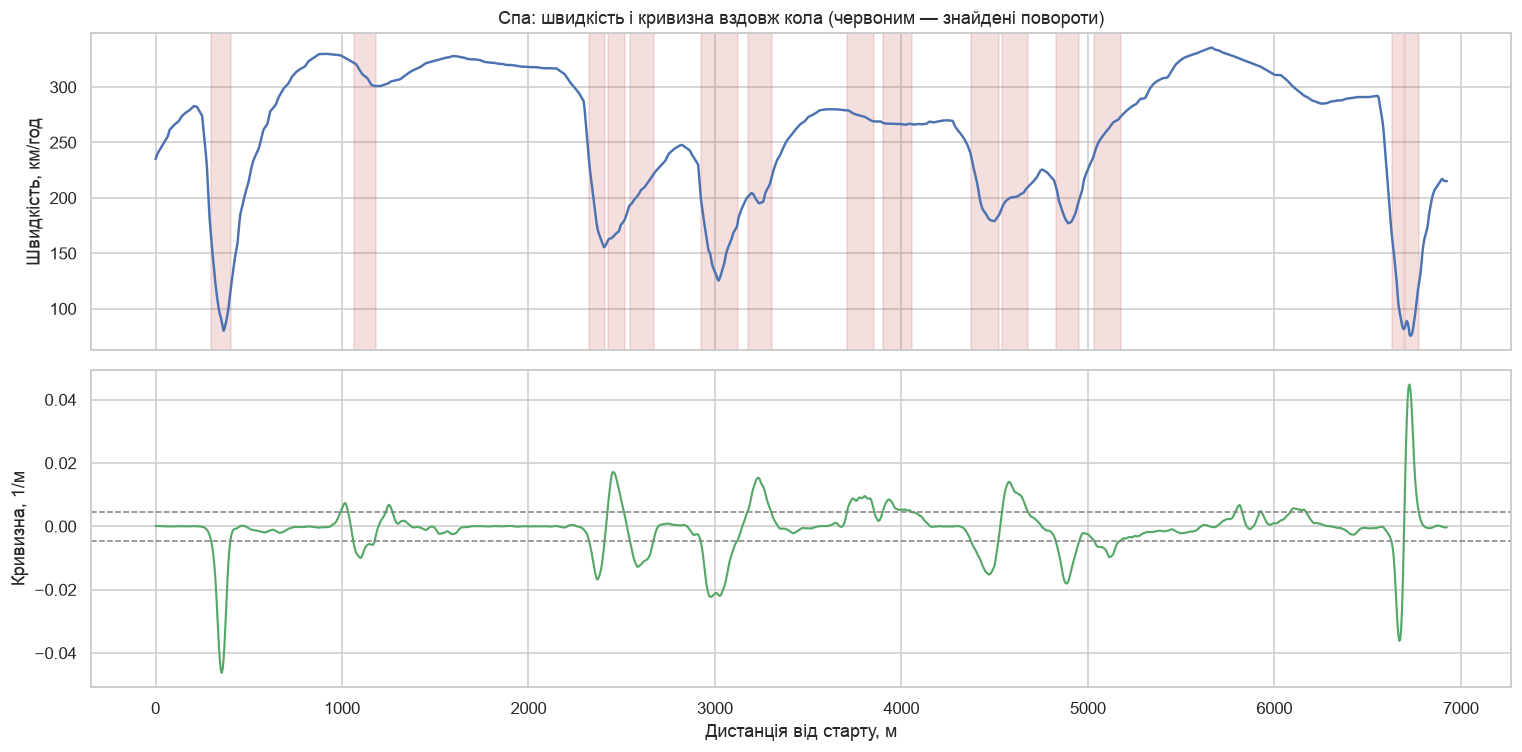

In [5]:
# Профіль швидкості й кривизни вздовж кола
fig, ax = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax[0].plot(gref["distance"], gref["speed"], color=BLUE, linewidth=1.6)
for _, c in corners_spa.iterrows():
    ax[0].axvspan(c["start_m"], c["end_m"], alpha=.18, color=RED)
ax[0].set_ylabel("Швидкість, км/год")
ax[0].set_title("Спа: швидкість і кривизна вздовж кола (червоним — знайдені повороти)")

ax[1].plot(gref["distance"], k_ref, color=GREEN, linewidth=1.4)
ax[1].axhline(1/T.CORNER_MIN_RADIUS_M, ls="--", color="grey", lw=1)
ax[1].axhline(-1/T.CORNER_MIN_RADIUS_M, ls="--", color="grey", lw=1)
ax[1].set_ylabel("Кривизна, 1/м"); ax[1].set_xlabel("Дистанція від старту, м")

plt.tight_layout(); plt.show()

In [6]:
# Каталоги для решти трас
catalogues = {}
for name, meta in TRACKS.items():
    lp = T.fastest_laps(conn, name, 2026, "Qualifying")
    if lp.empty:
        continue
    r = lp.iloc[0]
    l = T.load_lap(conn, r.session_key, r.driver_id, r.date_start, float(r.lap_duration))
    if l is None:
        continue
    g = T.resample(l); kk = T.curvature(g)
    catalogues[name] = {"grid": g, "k": kk, "ref": r,
                        "corners": T.detect_corners(g, kk),
                        "straights": T.detect_straights(g, kk)}

summary = pd.DataFrame([{
    "траса": TRACKS[n]["коротко"],
    "довжина, м": round(c["grid"]["distance"].iloc[-1]),
    "знайдено поворотів": len(c["corners"]),
    "офіційно": TRACKS[n]["офіційно поворотів"],
    "лівих": int((c["corners"]["direction"] == "лівий").sum()),
    "правих": int((c["corners"]["direction"] == "правий").sum()),
    "найкрутіший радіус, м": int(c["corners"]["radius_m"].min()),
    "прямих >300 м": len(c["straights"]),
} for n, c in catalogues.items()])
summary

,траса,"довжина, м",знайдено поворотів,офіційно,лівих,правих,"найкрутіший радіус, м",прямих >300 м
0,Спа,6925,15,19,6,9,22,7
1,Хунгароринг,4310,14,14,6,8,28,2
2,Монако,3245,14,19,6,8,10,0
3,Сільверстоун,5810,15,18,6,9,26,5


Кількість знайдених поворотів збігається з офіційною лише на Хунгаторингу. На решті трас
алгоритм знаходить на 3–5 менше — і це не помилка, а різниця у визначенні.

Офіційна нумерація включає плавні вигини, які за кривизною поворотами не є: машина проходить їх
без зниження швидкості. Алгоритм рахує поворотом ділянку, крутішу за радіус 220 м зі зміною
напрямку більше ніж на 25°. Нам потрібне саме таке визначення: місця, де пілот реально втрачає
або виграє час.

## 2. Помилка вирівнювання, яку довелось виправити

Щоб порівнювати пілотів, треба зіставити їхні кола з еталонним. Перший підхід був простим:
перевести дистанцію в частку кола й накласти вікна поворотів по частках.

Він дав нефізичні результати — 316 км/год у повороті радіусом 59 метрів і різницю між
напарниками у 200 км/год. Причина: якщо у зрізі телеметрії бракує точок на початку або в кінці
(а таке трапляється), уся вісь дистанції зсувається, і вікно повороту накладається не на той
відрізок траси.

Правильний спосіб — **геометрична прив'язка**: для кожної точки пілота шукаємо найближчу точку
еталонної траєкторії. Зсуви й різні траєкторії тоді не мають значення. Пошук обмежений вікном
попереду попередньої точки, інакше на паралельних ділянках найближча точка «перестрибує»
на сусідню пряму.

Нижче — перевірка, що після виправлення значення фізично можливі.

In [7]:
def collect(track_name, session="Qualifying", kind="corner"):
    """Показники всіх пілотів на всіх ділянках траси."""
    c = catalogues[track_name]
    sections = c["corners"] if kind == "corner" else c["straights"]
    lp = T.fastest_laps(conn, track_name, 2026, session)
    out = []
    for _, r in lp.iterrows():
        l = T.load_lap(conn, r.session_key, r.driver_id, r.date_start, float(r.lap_duration))
        if l is None:
            continue
        g = T.resample(l)
        m = T.driver_section_metrics(g, c["grid"], sections, kind)
        if m.empty:
            continue
        m["driver"], m["team"], m["lap_time"] = r.driver, r.team, float(r.lap_duration)
        out.append(m)
    return pd.concat(out, ignore_index=True)

spa_corners = collect("Belgian Grand Prix")
print("рядків пілот×поворот:", len(spa_corners), "| пілотів:", spa_corners["driver"].nunique())

tight = corners_spa.nsmallest(3, "radius_m")[["corner", "radius_m", "angle_deg"]]
check = (spa_corners[spa_corners["corner"].isin(tight["corner"])]
         .groupby("corner")["min_speed"].agg(["min", "max", "mean"]).round(0))
print("\nшвидкість в апексі найкрутіших поворотів (усі 22 пілоти):")
tight.merge(check.reset_index(), on="corner")

рядків пілот×поворот: 324 | пілотів: 22

швидкість в апексі найкрутіших поворотів (усі 22 пілоти):


,corner,radius_m,angle_deg,min,max,mean
0,1,22,149,77,84,80.0
1,15,22,113,72,82,77.0
2,14,28,83,77,92,82.0


У поворотах радіусом 22 метри всі 22 пілоти проходять апекс на 72–92 км/год. Це фізично
осмислений діапазон, і розкид між пілотами тепер вимірюється одиницями км/год, а не сотнями.

## 3. Дуелі напарників у поворотах

Порівняння напарників — єдиний спосіб виміряти пілота окремо від машини. В основному аналізі
ми знайшли, що Антонеллі швидший за Расселла на 0.432 с/коло. Тепер подивимось, **де саме**
ця перевага виникає.

In [8]:
def duel(df, team, value="min_speed"):
    pv = df[df["team"] == team].pivot_table(index="corner", columns="driver", values=value).dropna()
    if pv.shape[1] != 2:
        return None
    a, b = pv.columns
    out = corners_spa[["corner", "direction", "angle_deg", "radius_m"]].merge(
        pv.reset_index().rename_axis(None, axis=1), on="corner")
    out["різниця"] = (out[a] - out[b]).round(1)
    return out

mercedes = duel(spa_corners, "Mercedes")
mercedes

,corner,direction,angle_deg,radius_m,ANT,RUS,різниця
0,1,правий,149,22,80.0,79.0,1.0
1,2,правий,47,100,301.0,304.0,-3.0
2,3,правий,57,59,156.0,157.0,-1.0
3,4,лівий,61,58,161.0,163.0,-2.0
4,5,правий,73,78,194.0,193.0,1.0
5,6,правий,179,45,125.0,125.0,0.0
6,7,лівий,78,65,195.0,197.0,-2.0
7,8,лівий,69,105,269.0,266.0,3.0
8,9,лівий,54,118,266.0,263.0,3.0
9,10,правий,93,66,179.0,180.0,-1.0


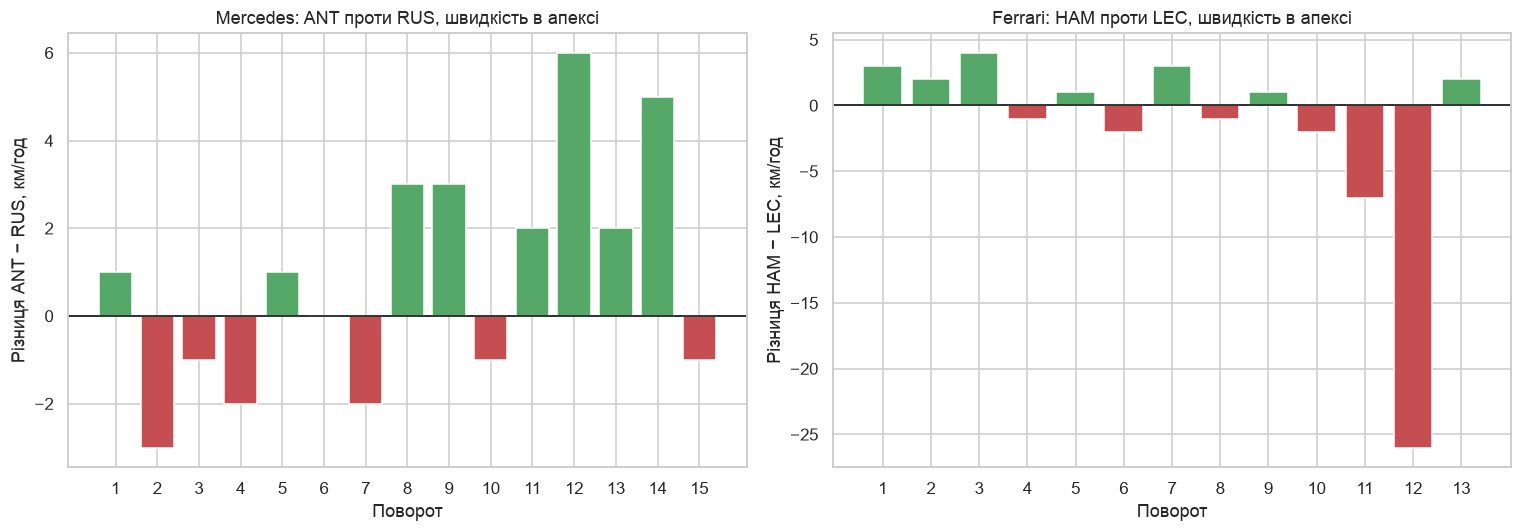

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

pairs = [("Mercedes", "ANT", "RUS"), ("Ferrari", "HAM", "LEC")]
for i, (team, a, b) in enumerate(pairs):
    t = duel(spa_corners, team)
    if t is None:
        continue
    colors = [GREEN if v > 0 else RED for v in t["різниця"]]
    ax[i].bar(t["corner"], t["різниця"], color=colors)
    ax[i].axhline(0, color="black", lw=1)
    ax[i].set_title(f"{team}: {a} проти {b}, швидкість в апексі")
    ax[i].set_xlabel("Поворот"); ax[i].set_ylabel(f"Різниця {a} − {b}, км/год")
    ax[i].set_xticks(t["corner"])

plt.tight_layout(); plt.show()

In [10]:
# Зведення по всіх командах: середня різниця між напарниками в поворотах
rows = []
for team, g in spa_corners.groupby("team"):
    pv = g.pivot_table(index="corner", columns="driver", values="min_speed").dropna()
    if pv.shape[1] != 2:
        continue
    a, b = pv.columns
    d = pv[a] - pv[b]
    rows.append({"команда": team, "пара": f"{a} − {b}",
                 "середня різниця, км/год": round(d.mean(), 1),
                 "макс перевага одного": round(d.max(), 1),
                 "макс перевага іншого": round(d.min(), 1),
                 "поворотів, де перший швидший": int((d > 0).sum()),
                 "усього поворотів": len(d)})
pd.DataFrame(rows).sort_values("середня різниця, км/год")

,команда,пара,"середня різниця, км/год",макс перевага одного,макс перевага іншого,"поворотів, де перший швидший",усього поворотів
9,Red Bull Racing,HAD − VER,-2.8,2.0,-10.0,3,15
10,Williams,ALB − SAI,-2.5,3.0,-10.0,4,15
8,Racing Bulls,LAW − LIN,-2.4,6.0,-8.0,1,13
4,Ferrari,HAM − LEC,-1.8,4.0,-26.0,7,13
1,Aston Martin,ALO − STR,-0.2,4.0,-4.0,5,15
0,Alpine,COL − GAS,0.2,9.0,-6.0,7,15
3,Cadillac,BOT − PER,0.4,7.0,-8.0,8,15
6,McLaren,NOR − PIA,0.5,6.0,-4.0,6,13
7,Mercedes,ANT − RUS,0.9,6.0,-3.0,8,15
2,Audi,BOR − HUL,1.5,7.0,-6.0,10,15


## 4. Прямі: як тримається тяга

За регламентом 2026 року близько половини потужності дає електрична частина, і запас енергії
обмежений. Тому цікаво не лише те, якої максимальної швидкості досягає машина, а й **чи тримає
вона її до кінця прямої**.

Щоб відокремити падіння швидкості через вичерпання енергії від звичайного гальмування,
беремо лише точки, де педаль гальма не натиснута.

In [11]:
c = catalogues["Belgian Grand Prix"]
kemmel = c["straights"].head(1)
print(f"найдовша пряма: {kemmel.iloc[0]['start_m']:.0f} → {kemmel.iloc[0]['end_m']:.0f} м "
      f"(довжина {kemmel.iloc[0]['length_m']:.0f} м)")

lp = T.fastest_laps(conn, "Belgian Grand Prix", 2026, "Qualifying")
traces = {}
rows = []
for _, r in lp.iterrows():
    l = T.load_lap(conn, r.session_key, r.driver_id, r.date_start, float(r.lap_duration))
    if l is None:
        continue
    g = T.resample(l)
    ref_dist = T.project_onto_reference(g, c["grid"])
    m = (ref_dist >= kemmel.iloc[0]["start_m"]) & (ref_dist <= kemmel.iloc[0]["end_m"])
    seg = g[m].copy()
    seg["ref_dist"] = ref_dist[m]
    if len(seg) < 20:
        continue
    traces[r.driver] = seg
    on_power = seg[seg["brake"] < 5]
    rows.append({
        "driver": r.driver, "team": r.team,
        "вхід": round(seg["speed"].iloc[0]),
        "макс": round(seg["speed"].max()),
        "на тязі до кінця": round(on_power["speed"].iloc[-1]) if len(on_power) else np.nan,
        "приріст": round(seg["speed"].max() - seg["speed"].iloc[0]),
        "де досягнуто макс, %": round(
            (seg.loc[seg["speed"].idxmax(), "ref_dist"] - kemmel.iloc[0]["start_m"])
            / kemmel.iloc[0]["length_m"] * 100),
    })
straight_tbl = pd.DataFrame(rows).sort_values("макс", ascending=False)
straight_tbl

найдовша пряма: 1275 → 2325 м (довжина 1050 м)


,driver,team,вхід,макс,на тязі до кінця,приріст,"де досягнуто макс, %"
5,HAM,Ferrari,304,330,294,26,34
0,ANT,Mercedes,306,328,295,22,30
1,VER,Red Bull Racing,294,328,282,34,41
3,RUS,Mercedes,306,327,300,21,32
4,LEC,Ferrari,304,327,285,23,39
7,LIN,Racing Bulls,310,327,291,17,28
9,HAD,Red Bull Racing,292,327,291,35,40
18,BOT,Cadillac,303,325,292,22,29
16,ALB,Williams,300,325,309,25,29
14,SAI,Williams,303,325,304,22,34


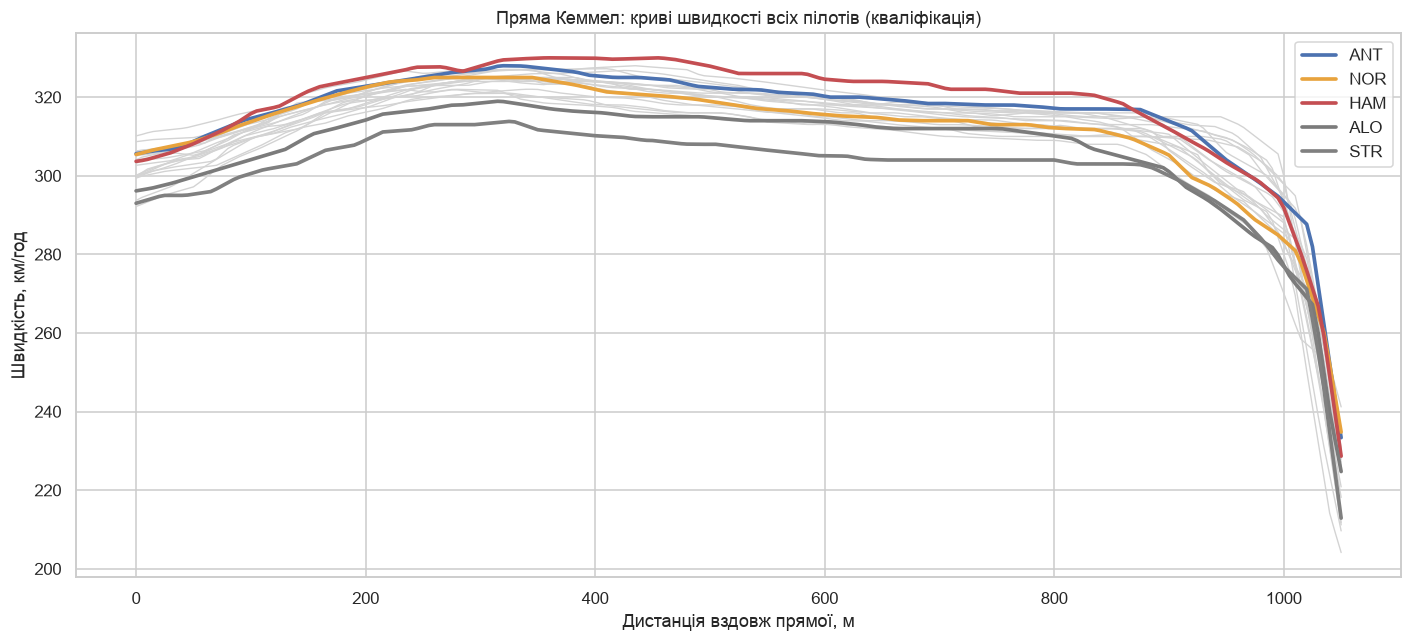

In [12]:
plt.figure(figsize=(13, 6))
highlight = {"HAM": RED, "ANT": BLUE, "NOR": "#E8A33D", "STR": "grey", "ALO": "#7B7B7B"}
for drv, seg in traces.items():
    x = seg["ref_dist"] - kemmel.iloc[0]["start_m"]
    if drv in highlight:
        plt.plot(x, seg["speed"], color=highlight[drv], linewidth=2.4, label=drv, zorder=3)
    else:
        plt.plot(x, seg["speed"], color="lightgrey", linewidth=.9, zorder=1)
plt.title("Пряма Кеммел: криві швидкості всіх пілотів (кваліфікація)")
plt.xlabel("Дистанція вздовж прямої, м"); plt.ylabel("Швидкість, км/год")
plt.legend(); plt.tight_layout(); plt.show()

## 5. Де саме команди втрачають час

Головне питання: аутсайдери відстають через брак потужності чи через поведінку в поворотах?
Порівняємо дефіцит на прямій із дефіцитом у поворотах.

In [13]:
corner_deficit = (spa_corners.assign(
        deficit=lambda d: d.groupby("corner")["min_speed"].transform("max") - d["min_speed"])
    .groupby("team")["deficit"].mean())

straight_deficit = (straight_tbl.assign(
        deficit=lambda d: d["макс"].max() - d["макс"])
    .groupby("team")["deficit"].mean())

loss = pd.DataFrame({
    "у поворотах, км/год": corner_deficit.round(1),
    "на прямій, км/год":   straight_deficit.round(1),
}).sort_values("у поворотах, км/год")
loss["співвідношення"] = (loss["у поворотах, км/год"] /
                          loss["на прямій, км/год"].replace(0, np.nan)).round(1)
loss

,"у поворотах, км/год","на прямій, км/год",співвідношення
team,,,
Ferrari,3.9,1.5,2.6
McLaren,5.8,5.0,1.2
Mercedes,6.6,2.5,2.6
Audi,7.5,6.5,1.2
Racing Bulls,7.6,5.5,1.4
Red Bull Racing,8.3,2.5,3.3
Alpine,11.0,5.0,2.2
Haas F1 Team,11.6,7.5,1.5
Williams,12.6,5.0,2.5


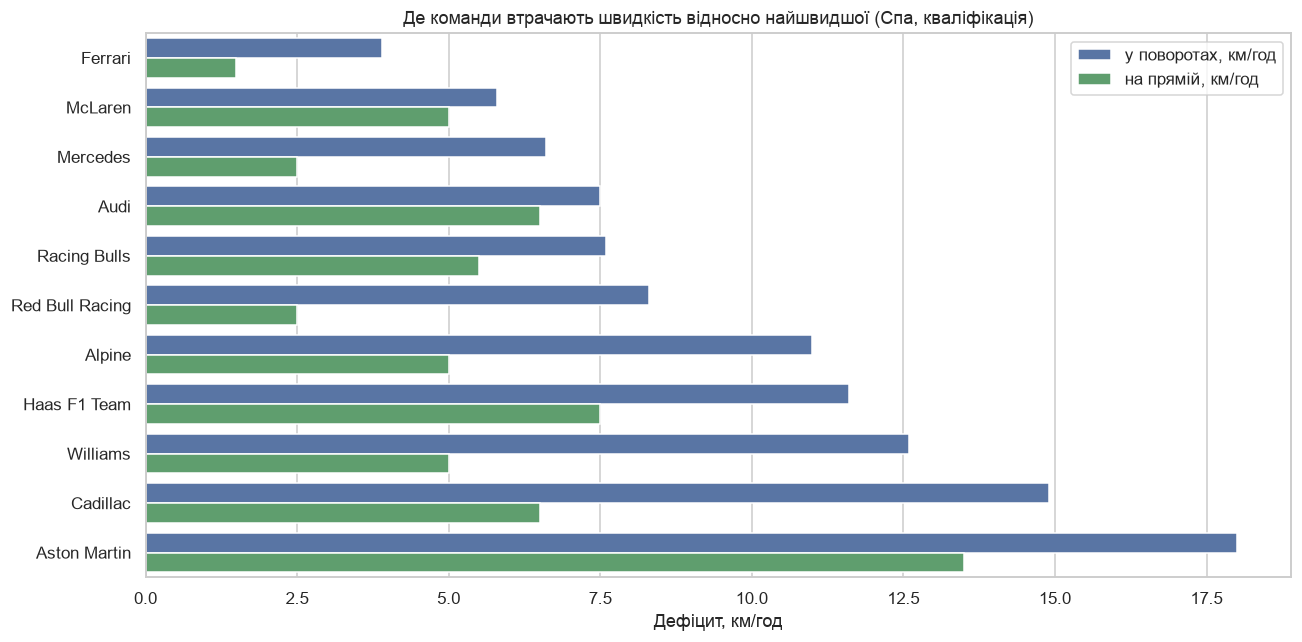

In [14]:
plot_df = loss.reset_index().melt(id_vars="team",
                                  value_vars=["у поворотах, км/год", "на прямій, км/год"],
                                  var_name="де", value_name="дефіцит")

plt.figure(figsize=(12, 6))
sns.barplot(plot_df, y="team", x="дефіцит", hue="де", palette=[BLUE, GREEN])
plt.title("Де команди втрачають швидкість відносно найшвидшої (Спа, кваліфікація)")
plt.xlabel("Дефіцит, км/год"); plt.ylabel(""); plt.legend(title="")
plt.tight_layout(); plt.show()

## 6. Експорт для Power BI

In [15]:
from pathlib import Path
out = Path("export/telemetry")
out.mkdir(parents=True, exist_ok=True)

all_corners = []
for name, c in catalogues.items():
    cc = c["corners"].copy()
    cc.insert(0, "track", TRACKS[name]["коротко"])
    cc.insert(1, "meeting_name", name)
    all_corners.append(cc)
corner_catalogue = pd.concat(all_corners, ignore_index=True)
corner_catalogue.to_csv(out / "corner_catalogue.csv", index=False)

spa_corners.assign(track="Спа", meeting_name="Belgian Grand Prix") \
    .to_csv(out / "driver_corner_metrics_spa.csv", index=False)
straight_tbl.assign(track="Спа", straight="Kemmel") \
    .to_csv(out / "driver_straight_metrics_spa.csv", index=False)

for f in sorted(out.glob("*.csv")):
    print(f"{f.name:<38} {f.stat().st_size/1024:>7.1f} КБ")

corner_catalogue.csv                       6.9 КБ
driver_corner_metrics_spa.csv             24.2 КБ
driver_straight_metrics_spa.csv            1.1 КБ


## Висновки

**1. Каталог поворотів будується автоматично і відтворює реальну геометрію.** Алгоритм упізнав
Ла-Сурс, О-Руж, Бус-Стоп і пряму Кеммел, не маючи про них жодних відомостей. На Хунгаторингу
кількість знайдених поворотів збіглася з офіційною точно (14), а найкрутіший радіус у Монако
вийшов 10 метрів — це шпилька Гранд-Готель, найповільніший поворот чемпіонату. Монако також
виявилось єдиною трасою, де немає жодної прямої довшої за 300 метрів.

**2. Геометрична прив'язка обов'язкова.** Вирівнювання за часткою кола давало 316 км/год у
повороті радіусом 59 метрів. Помилка була тиха: числа виглядали як дані, а не як збій. Спіймала
її перевірка на фізичну можливість — тому такі перевірки варто робити завжди, а не лише коли
щось виглядає підозріло.

**3. Напарники в поворотах майже нерозрізненні.** Середня різниця між напарниками — від −2.8
до +2.1 км/год в апексі. Навіть у Mercedes, де за сезон Антонеллі виграє 0.432 с/коло, на Спа
різниця в поворотах становить лише 0.9 км/год на користь Антонеллі. Тобто перевага набирається
не в одному місці, а розмазана по трасі — і на окремо взятому етапі може взагалі не проявитись.

**4. Аутсайдери програють і в поворотах, і на прямій — але по-різному.** У більшості команд
дефіцит на прямій малий (1.5–7.5 км/год), а основні втрати в поворотах: у Red Bull
співвідношення 3.3, у Ferrari й Mercedes — 2.6. Aston Martin вибивається: 18.0 км/год у
поворотах при 13.5 км/год на прямій, тобто співвідношення лише 1.3. Це **єдина команда з
по-справжньому великим дефіцитом на прямій**, тож її проблема не зводиться до аеродинаміки
в поворотах — у машини бракує ще й швидкості на тязі.

### Обмеження

- Частота 4 Гц не дозволяє визначати точку початку гальмування.
- Каталог будується за одним еталонним колом; за іншого еталона межі поворотів можуть
  трохи зсунутись.
- Порівнюються найшвидші кола кваліфікації, тобто пікова форма, а не типова гоночна.
- Аналіз «де втрачається час» зроблено на одній трасі (Спа). Спа має довгі прямі, тому
  співвідношення втрат тут зміщене на користь потужності; на Монако картина буде іншою.
- Кількість знайдених поворотів залежить від порога кривизни; поріг обрано так, щоб
  відсікати плавні вигини, які не коштують часу.